# CNN

## Import Images

In [1]:
import numpy as np
from pathlib import Path
import gzip

%load_ext autoreload
%autoreload 2

# Read info from compressed binary format
BASE_DIR = Path.cwd().parent

# Labels
label_path = BASE_DIR / "MNIST" / 'train-labels-idx1-ubyte.gz'
with gzip.open(label_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_labels = int.from_bytes(f.read(4)) # Number of labels
    labels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of items according to file: {n_labels}")
print(f"actual number of items: {len(labels)}")

# Images
img_path = BASE_DIR / "MNIST" / 'train-images-idx3-ubyte.gz'
with gzip.open(img_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_images = int.from_bytes(f.read(4)) # Number of images
    n_rows = int.from_bytes(f.read(4))
    n_cols = int.from_bytes(f.read(4))
    pixels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of images according to file: {n_labels}")
print(f"n_rows: {n_rows}")
print(f"n_cols: {n_cols}")
print(f"actual number of images: {len(pixels) // (n_rows * n_cols)}")

imgs = pixels.reshape(n_images, n_rows, n_cols)
print(f"number of reshapes images: {len(imgs)}")

number of items according to file: 60000
actual number of items: 60000
number of images according to file: 60000
n_rows: 28
n_cols: 28
actual number of images: 60000
number of reshapes images: 60000


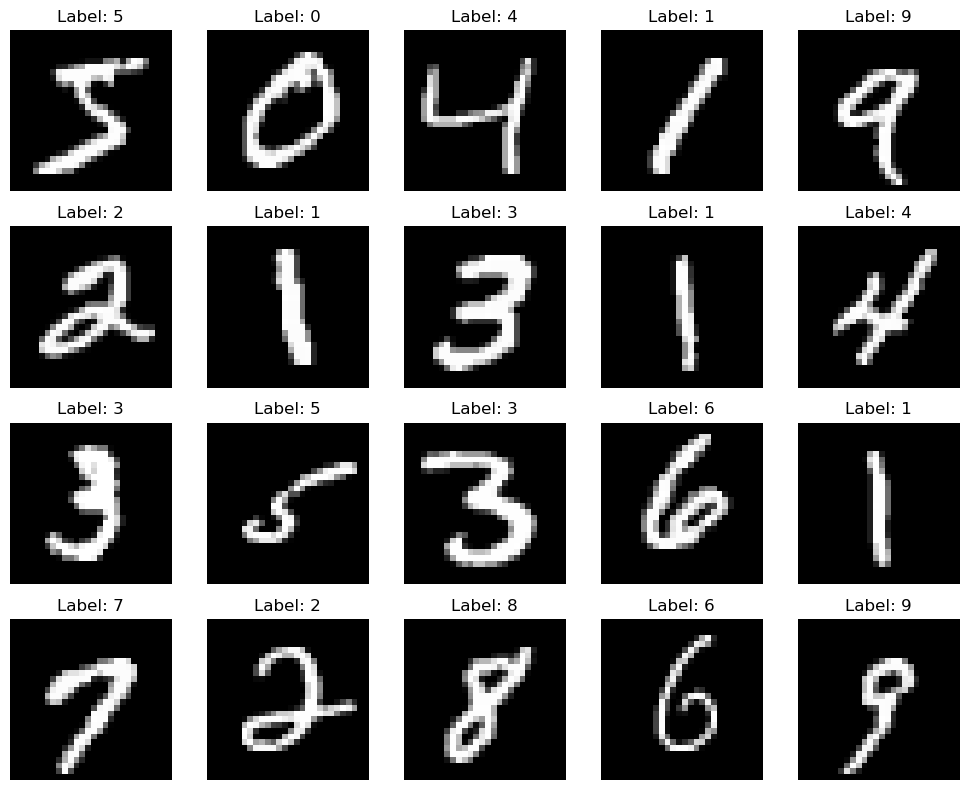

In [2]:
import matplotlib.pyplot as plt

def show_image_grid(imgs, labels, preds=None, ids=range(20), cols=5):
    rows = int(np.ceil(len(ids) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).reshape(-1)

    for ax, id in zip(axes, ids):
        ax.imshow(imgs[id], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Label: {labels[id]}")
        if preds is not None:
            ax.set_title(f"Label: {labels[id]}\nPred: {preds[id]:.3f}")

    for ax in axes[len(ids):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_image_grid(imgs, labels, ids=range(20), cols=5)

In [3]:
indices = np.where(np.isin(labels, [0, 1]))[0]

filtered_imgs = imgs[indices]
print(filtered_imgs.shape)
filtered_labels = labels[indices]

shuffled_indices = np.random.permutation(len(filtered_imgs))
filtered_imgs = filtered_imgs[shuffled_indices]
filtered_labels = filtered_labels[shuffled_indices]

train_size = 80
val_size = 20

train_imgs = np.expand_dims(filtered_imgs[:train_size, :, :], axis=1)
train_labels = filtered_labels[:train_size].reshape(-1, 1)
val_imgs = np.expand_dims(filtered_imgs[train_size:train_size+val_size, :, :], axis=1)
val_labels = filtered_labels[train_size:train_size+val_size].reshape(-1, 1)

# Normalization
train_imgs = train_imgs / 255.0
val_imgs = val_imgs / 255.0

print(train_imgs.shape)
print(train_labels.shape)
print(val_imgs.shape)
print(val_labels.shape)

# show_image_grid(filtered_imgs, filtered_labels, ids=range(20), cols=5)

(12665, 28, 28)
(80, 1, 28, 28)
(80, 1)
(20, 1, 28, 28)
(20, 1)


In [4]:
from NNLibrary.nn_layer import LinearLayer, ConvLayer
from NNLibrary.pools import MaxPool, Flatten
from NNLibrary.activation import Sigmoid
from NNLibrary.loss import BinaryCrossEntropy


BCE = BinaryCrossEntropy()

conv1 = ConvLayer(kernel_size=3, out_channels=3)
sigmoid1 = Sigmoid()
pool1 = MaxPool(size=2, stride=2)
conv2 = ConvLayer(kernel_size=3, in_channels=3, out_channels=3)
sigmoid2 = Sigmoid()
pool2 = MaxPool(size=2, stride=2)
flatten = Flatten()
mlp = LinearLayer(in_dim=75, out_dim=1)
sigmoid3 = Sigmoid()


network = [conv1, sigmoid1, pool1, conv2, sigmoid2, pool2, flatten, mlp, sigmoid3]

In [ ]:
def forward(x, network):
    for layer in network:
        x = layer.forward(x)
    return x

def backprop(network, loss_fn, lr):
    grad = loss_fn.backward()
    for layer in reversed(network):
        grad = layer.backward(grad)

    for layer in network:
        if hasattr(layer, 'update'):
            layer.update(lr)


In [6]:
epochs = 20
lr = 0.01

train_losses = []
val_losses = []

for epoch in range(epochs):

    out = forward(val_imgs, network)
    val_loss = BCE.forward(out, val_labels)
    val_losses.append(val_loss)
    
    out = forward(train_imgs, network)
    train_loss = BCE.forward(out, train_labels)
    train_losses.append(train_loss)

    backprop(network, BCE, lr)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch}")

plt.plot(range(epochs), train_losses, label="train")
plt.plot(range(epochs), val_losses, label="val")
plt.legend()
plt.show()

Epoch: 0
Epoch: 5


KeyboardInterrupt: 

(1000, 1, 28, 28)


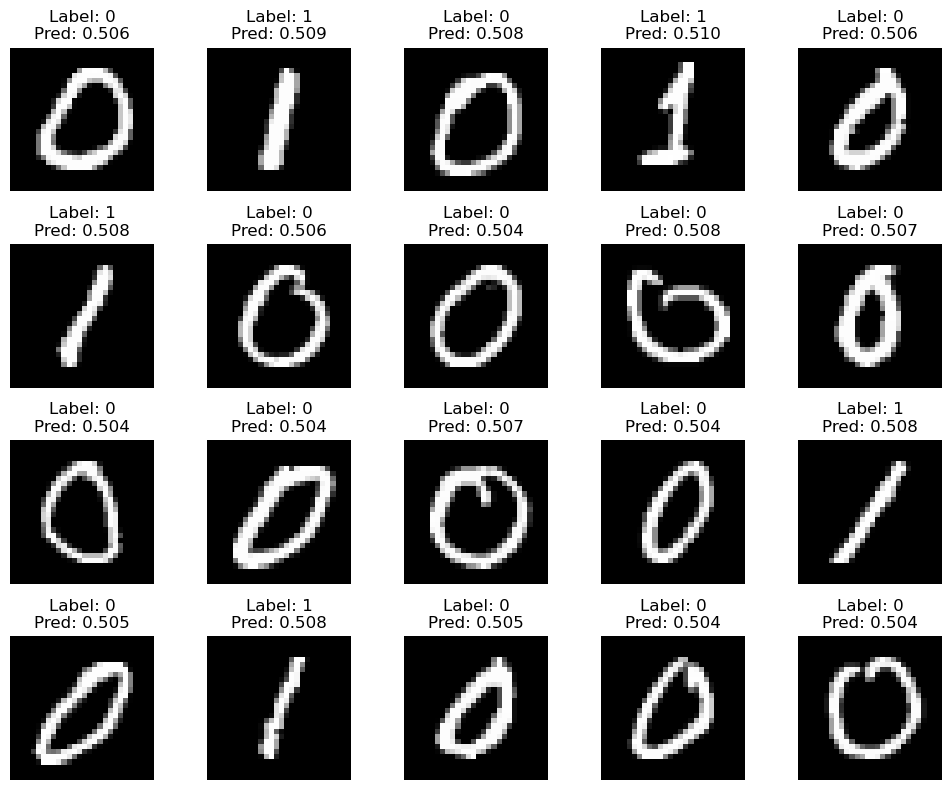

In [9]:
print(val_imgs.shape)

val_img_sample = val_imgs[0:20, :, :, :]
val_label_sample = val_labels[0:20]

val_pred_sample, loss = forward(val_img_sample, val_label_sample, batch_size=20)

show_image_grid(val_img_sample.reshape(20, 28, 28), val_label_sample.reshape(20), val_pred_sample.reshape(20), ids=range(20), cols=5)